## Setup

In [19]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [20]:
from tapas_gmm_modified.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm_modified.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm_modified.policy.models.tpgmm
from tapas_gmm_modified.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm_modified.utils.logging import setup_logger  # noqa: F401
from tapas_gmm_modified.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
task = "GrabBlueDrawer"
path = data_root / task / "demos"

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))

SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.uint8, is_shared=False),
    object_poses=TensorDict(
        fields={
            base__button: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__drawer: Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
            base__slide: Tensor(shape=torch.Size([7]), 

In [22]:
gt_pose_config = {}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'static',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [23]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([176, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([176]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([176, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([176, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([176, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([176, 3, 256, 256]), device=cpu, dt

In [24]:
tpgmm_config = TPGMMConfig(
    n_components=20,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,
    add_gripper_action=True,
    reg_shrink=1e-2,
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,
    #trans_cov_mask_t_pos_corr=False,
    em_steps=50,
    reg_init_diag=5e-4,  # 5
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    # gt_frames=[
    #    [0, 2,5],
    #    [0, 2,5],
    #    [0, 2,5],
    #    [0, 2,5],
    # ]
    gt_frames=[
        [0, 5],
        [5],
        [5],
        [0, 5],
    ],
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    components_prop_to_len=True,
    velocity_threshold=0.001,
    repeat_final_step=10,
    repeat_first_step=10,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [25]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-17 20:53:46.852 | INFO     |  Fitting AutoTPGMM
2025-08-17 20:53:46.852 | INFO     |  Segmenting trajectories


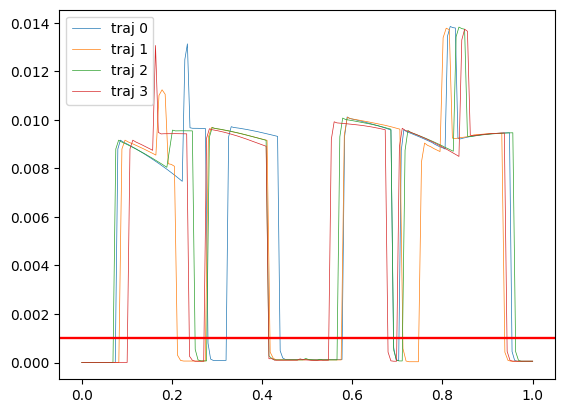

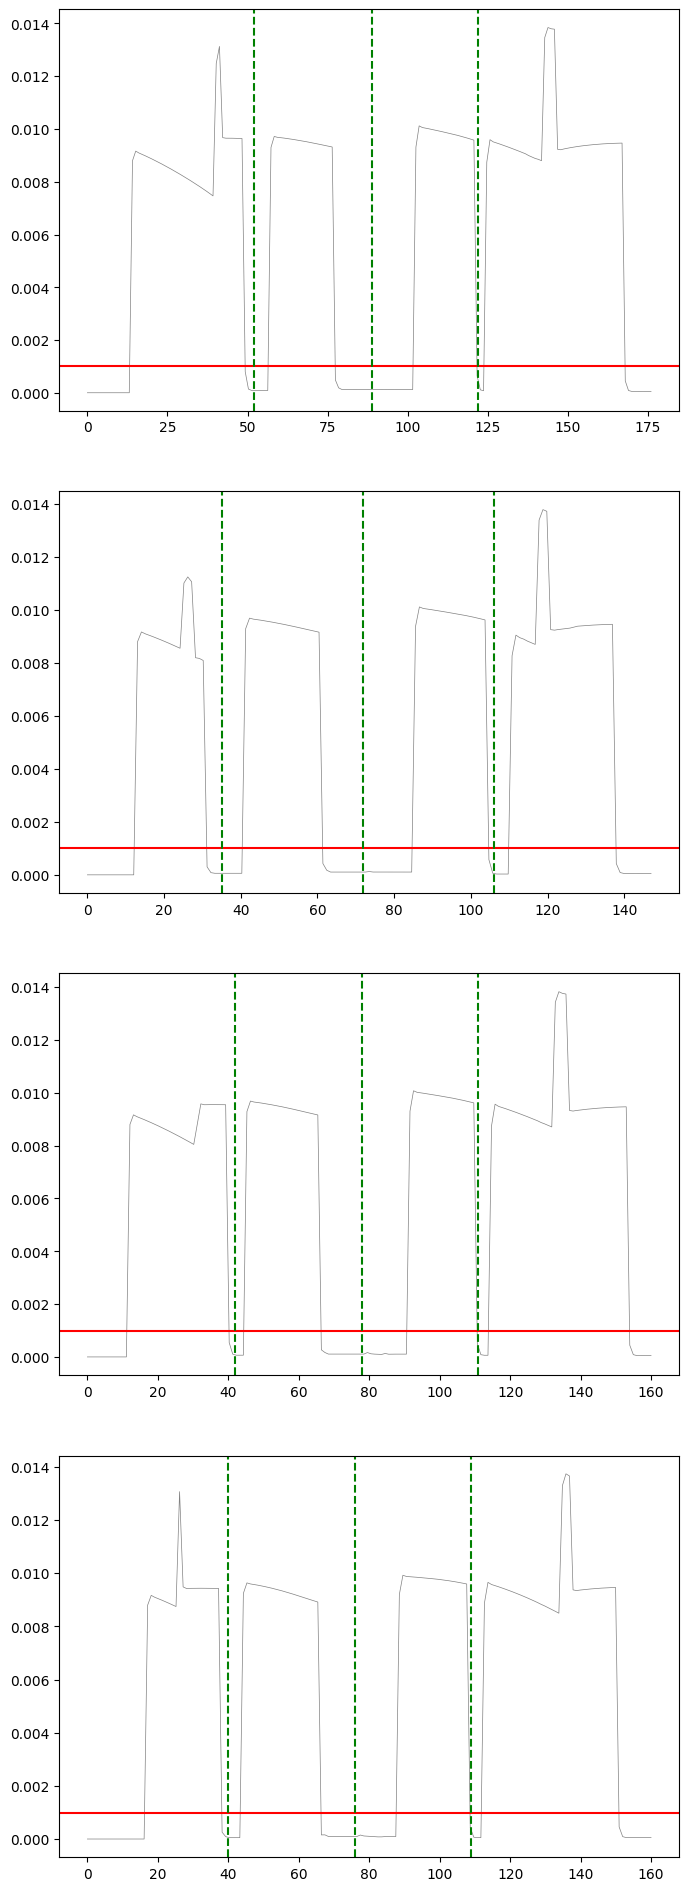

2025-08-17 20:53:47.054 | INFO     |  Creating segement of demos.
2025-08-17 20:53:47.057 | INFO     |  Creating segement of demos.
2025-08-17 20:53:47.059 | INFO     |  Creating segement of demos.
2025-08-17 20:53:47.061 | INFO     |  Creating segement of demos.
2025-08-17 20:53:47.063 | INFO     |  ... created 4 segments
2025-08-17 20:53:47.063 | INFO     |    Fitting candidate frame 1/10
2025-08-17 20:53:47.063 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-17 20:53:47.118 | INFO     |    Fitting candidate frame 2/10
2025-08-17 20:53:47.118 | INFO     |    Creating partial frame view of demos.


Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-17 20:53:47.212 | INFO     |    Fitting candidate frame 3/10
2025-08-17 20:53:47.212 | INFO     |    Creating partial frame view of demos.


...

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/4 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

((array([[3.35e+15, 3.76e+15, 4.11e+15, ..., 1.04e-14, 2.21e-15, 4.53e-16],
         [1.68e+14, 2.47e+14, 3.54e+14, ..., 9.68e-06, 3.55e-06, 1.27e-06],
         [7.70e+10, 1.51e+11, 2.85e+11, ..., 4.16e+05, 2.06e+05, 9.87e+04],
         [1.22e-01, 2.80e-01, 6.25e-01, ..., 3.53e+13, 2.45e+13, 1.65e+13],
         [6.85e-26, 3.03e-25, 1.30e-24, ..., 2.74e+15, 2.49e+15, 2.19e+15]]),
  array([[1.19e+09, 1.35e+09, 1.49e+09, 1.60e+09, 1.67e+09, 1.69e+09,
          1.67e+09, 1.60e+09, 1.49e+09, 1.35e+09, 1.19e+09, 1.02e+09,
          8.50e+08, 6.89e+08, 5.42e+08, 3.60e+08, 1.92e+08, 8.31e+07,
          2.90e+07, 8.20e+06, 1.87e+06, 3.48e+05, 5.23e+04, 6.40e+03,
          6.37e+02, 5.17e+01, 3.42e+00, 1.55e-02, 5.76e-04, 1.76e-05,
          4.44e-07, 9.20e-09, 1.57e-10, 2.21e-12, 9.89e-13, 4.56e-13,
          2.00e-13, 8.52e-14, 3.53e-14, 1.42e-14, 5.58e-15, 2.12e-15,
          7.86e-16, 2.83e-16, 9.88e-17, 3.23e-17, 1.03e-17, 3.18e-18,
          9.54e-19, 2.79e-19, 7.91e-20, 2.18e-20, 5.86e-21

In [26]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,)) # FittingStage.EM_HMM))


2025-08-17 20:53:53.089 | INFO     |  Did not specify time_based, deciding automatically.
2025-08-17 20:53:53.130 | WARNING  |  Skippig NaN Gaussians.


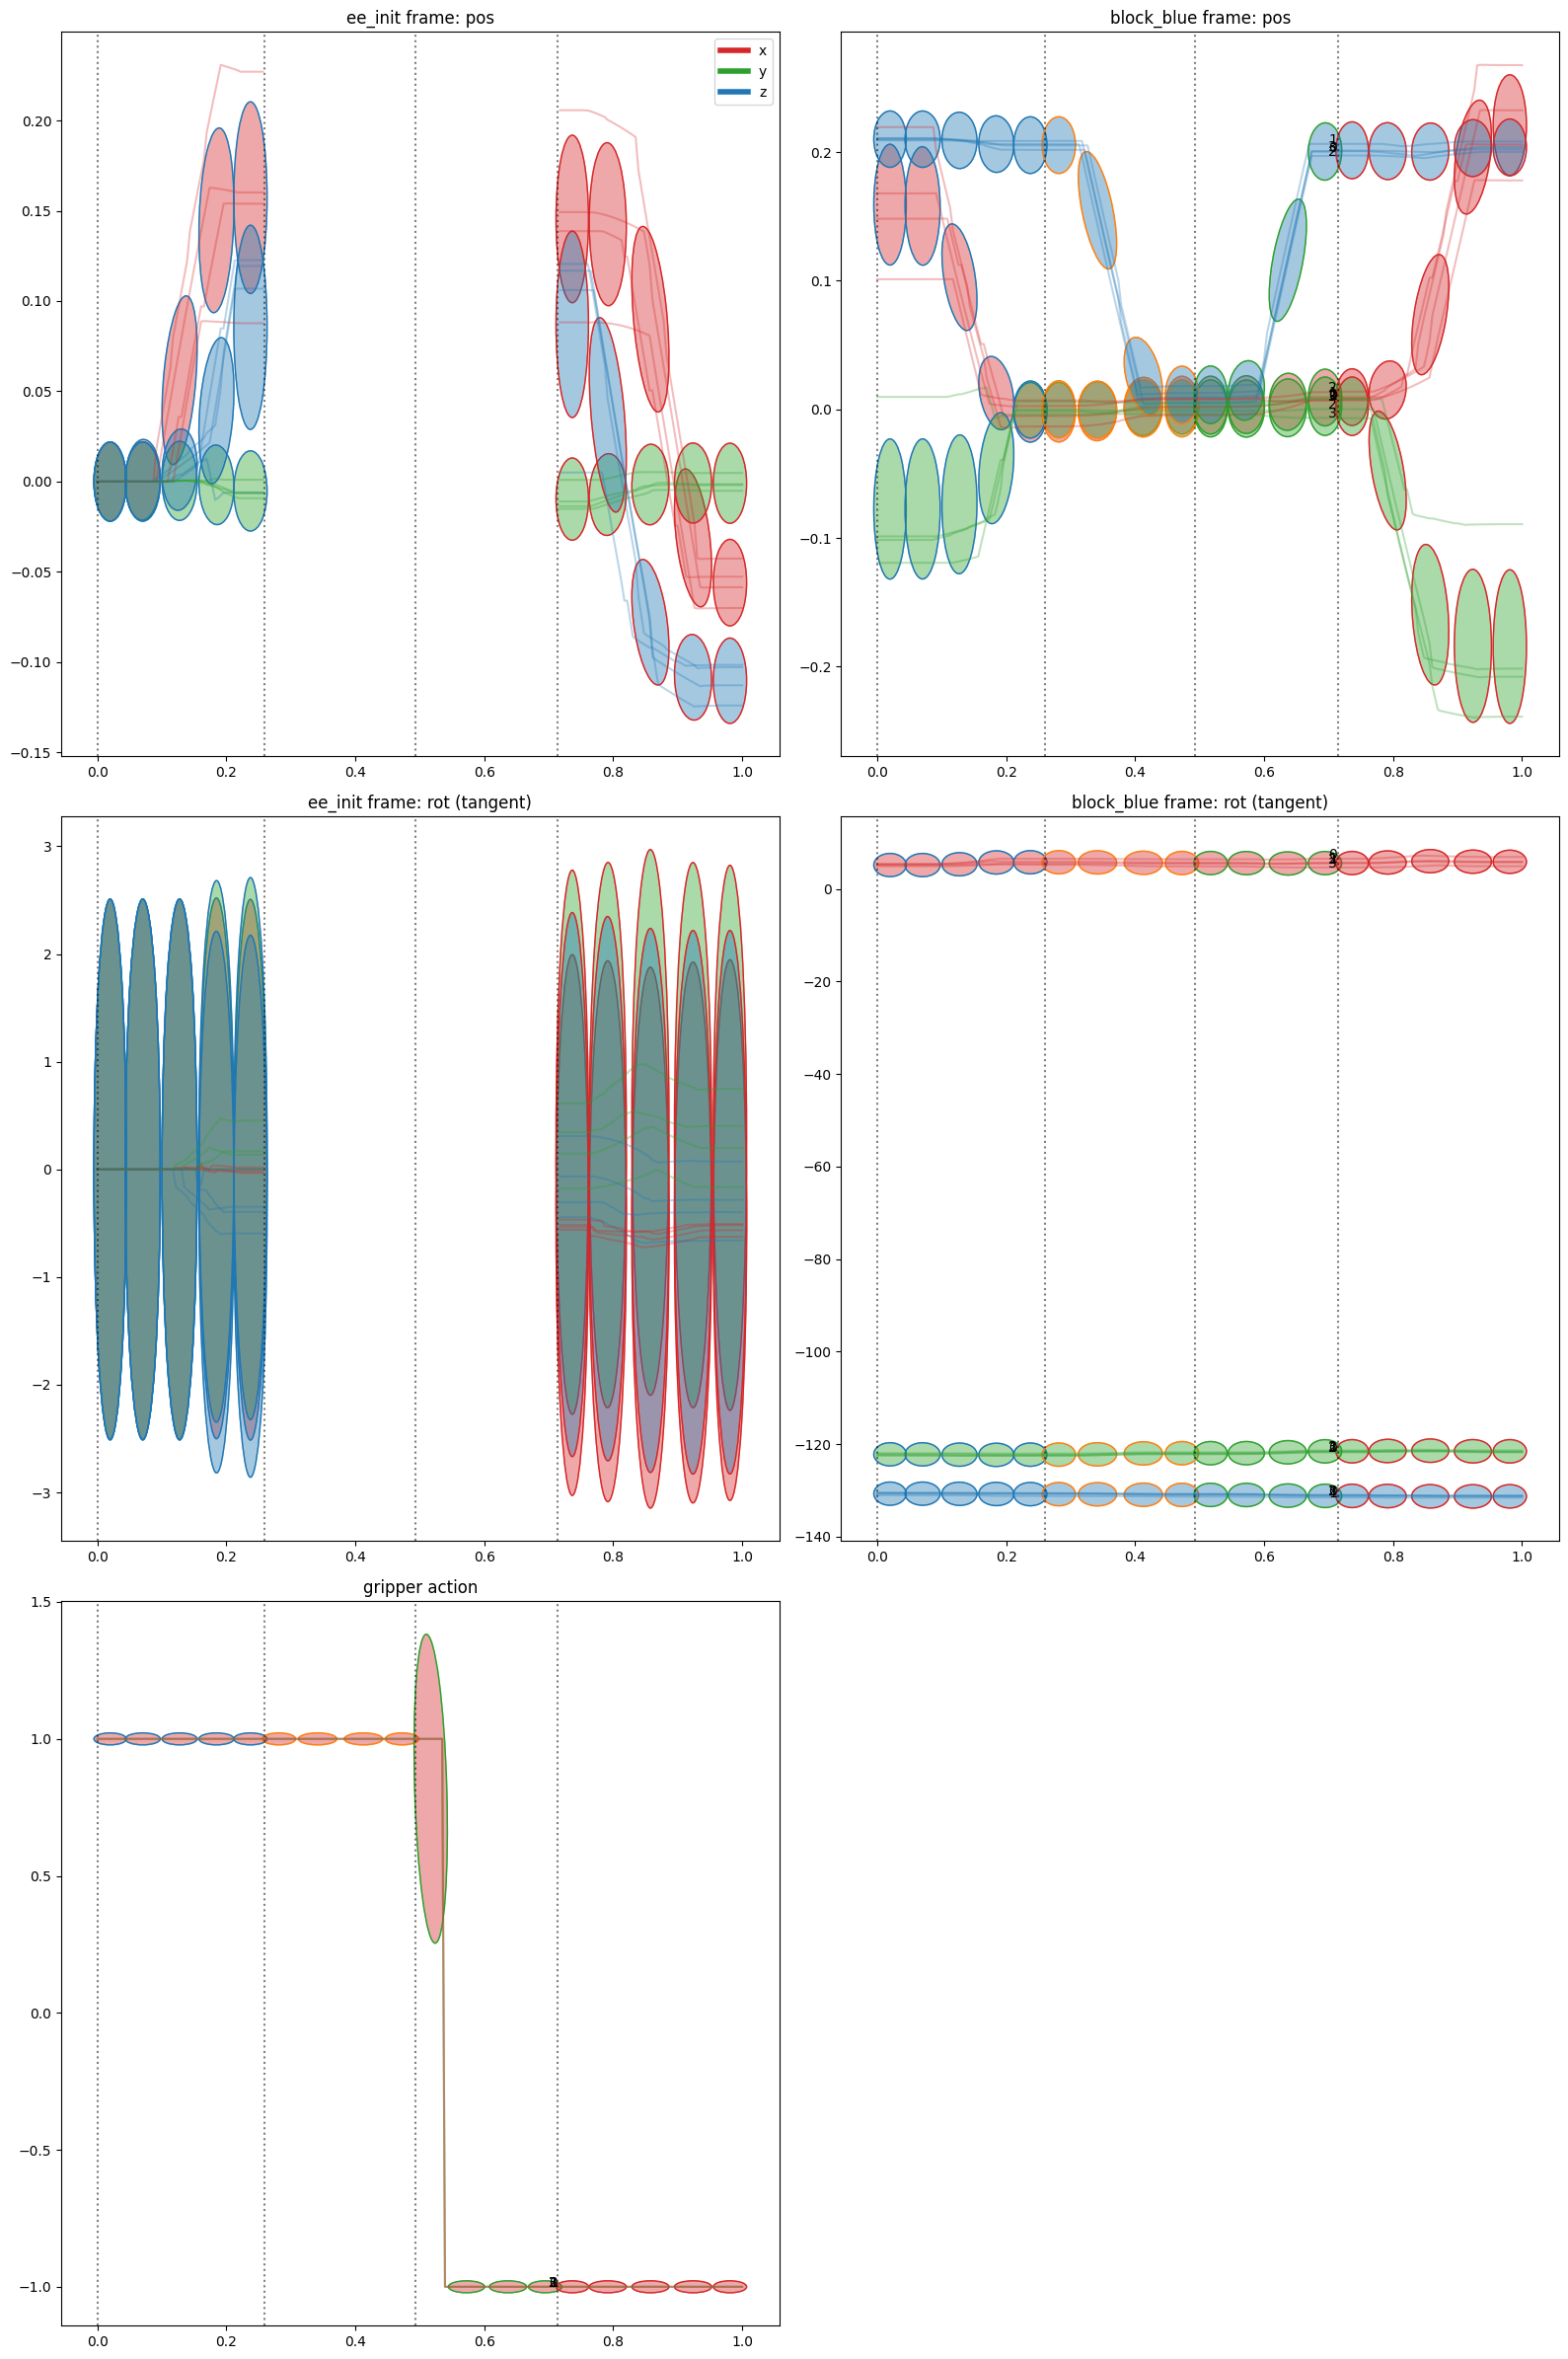

In [27]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [28]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-17 20:53:54.010 | INFO     |  Fitting AutoTPGMM


Fitting segments:   0%|          | 0/4 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[2.75e-023, 5.22e-024, 9.24e-025, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [1.00e+000, 1.00e+000, 1.00e+000, ..., 0.00e+000, 0.00e+000,
          0.00e+000],
         [0.00e+000, 4.65e-064, 1.12e-057, ..., 4.85e-196, 1.83e-214,
          2.54e-232],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 9.49e-001, 8.70e-001,
          7.02e-001],
         [0.00e+000, 0.00e+000, 0.00e+000, ..., 5.05e-002, 1.30e-001,
          2.98e-001]]),
  array([[1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000,
          1.00e+000, 1.00e+000, 1.00e+000, 1.00e+000, 9.95e-001, 9.73e-001,
          8.95e-001, 7.22e-001, 4.61e-001, 1.83e-001, 3.48e-002, 2.51e-003,
          5.52e-005, 3.05e-007, 3.56e-010, 7.39e-014, 2.32e-018, 9.32e-024,
          4.08e-030, 1.65e-037, 5.05e-046, 8.13e-057, 3.42e-069, 2.76e-083,
          3.92e-099, 9.60e-117, 4.11e-136, 3.22e-157, 9.46e-179, 1.12e-200,
          5.34e-223, 1.03e-245, 8.12e-269, 2.52e-292, 0.00e+000, 0.00e+000,
      

2025-08-17 20:54:00.719 | INFO     |  Did not specify time_based, deciding automatically.


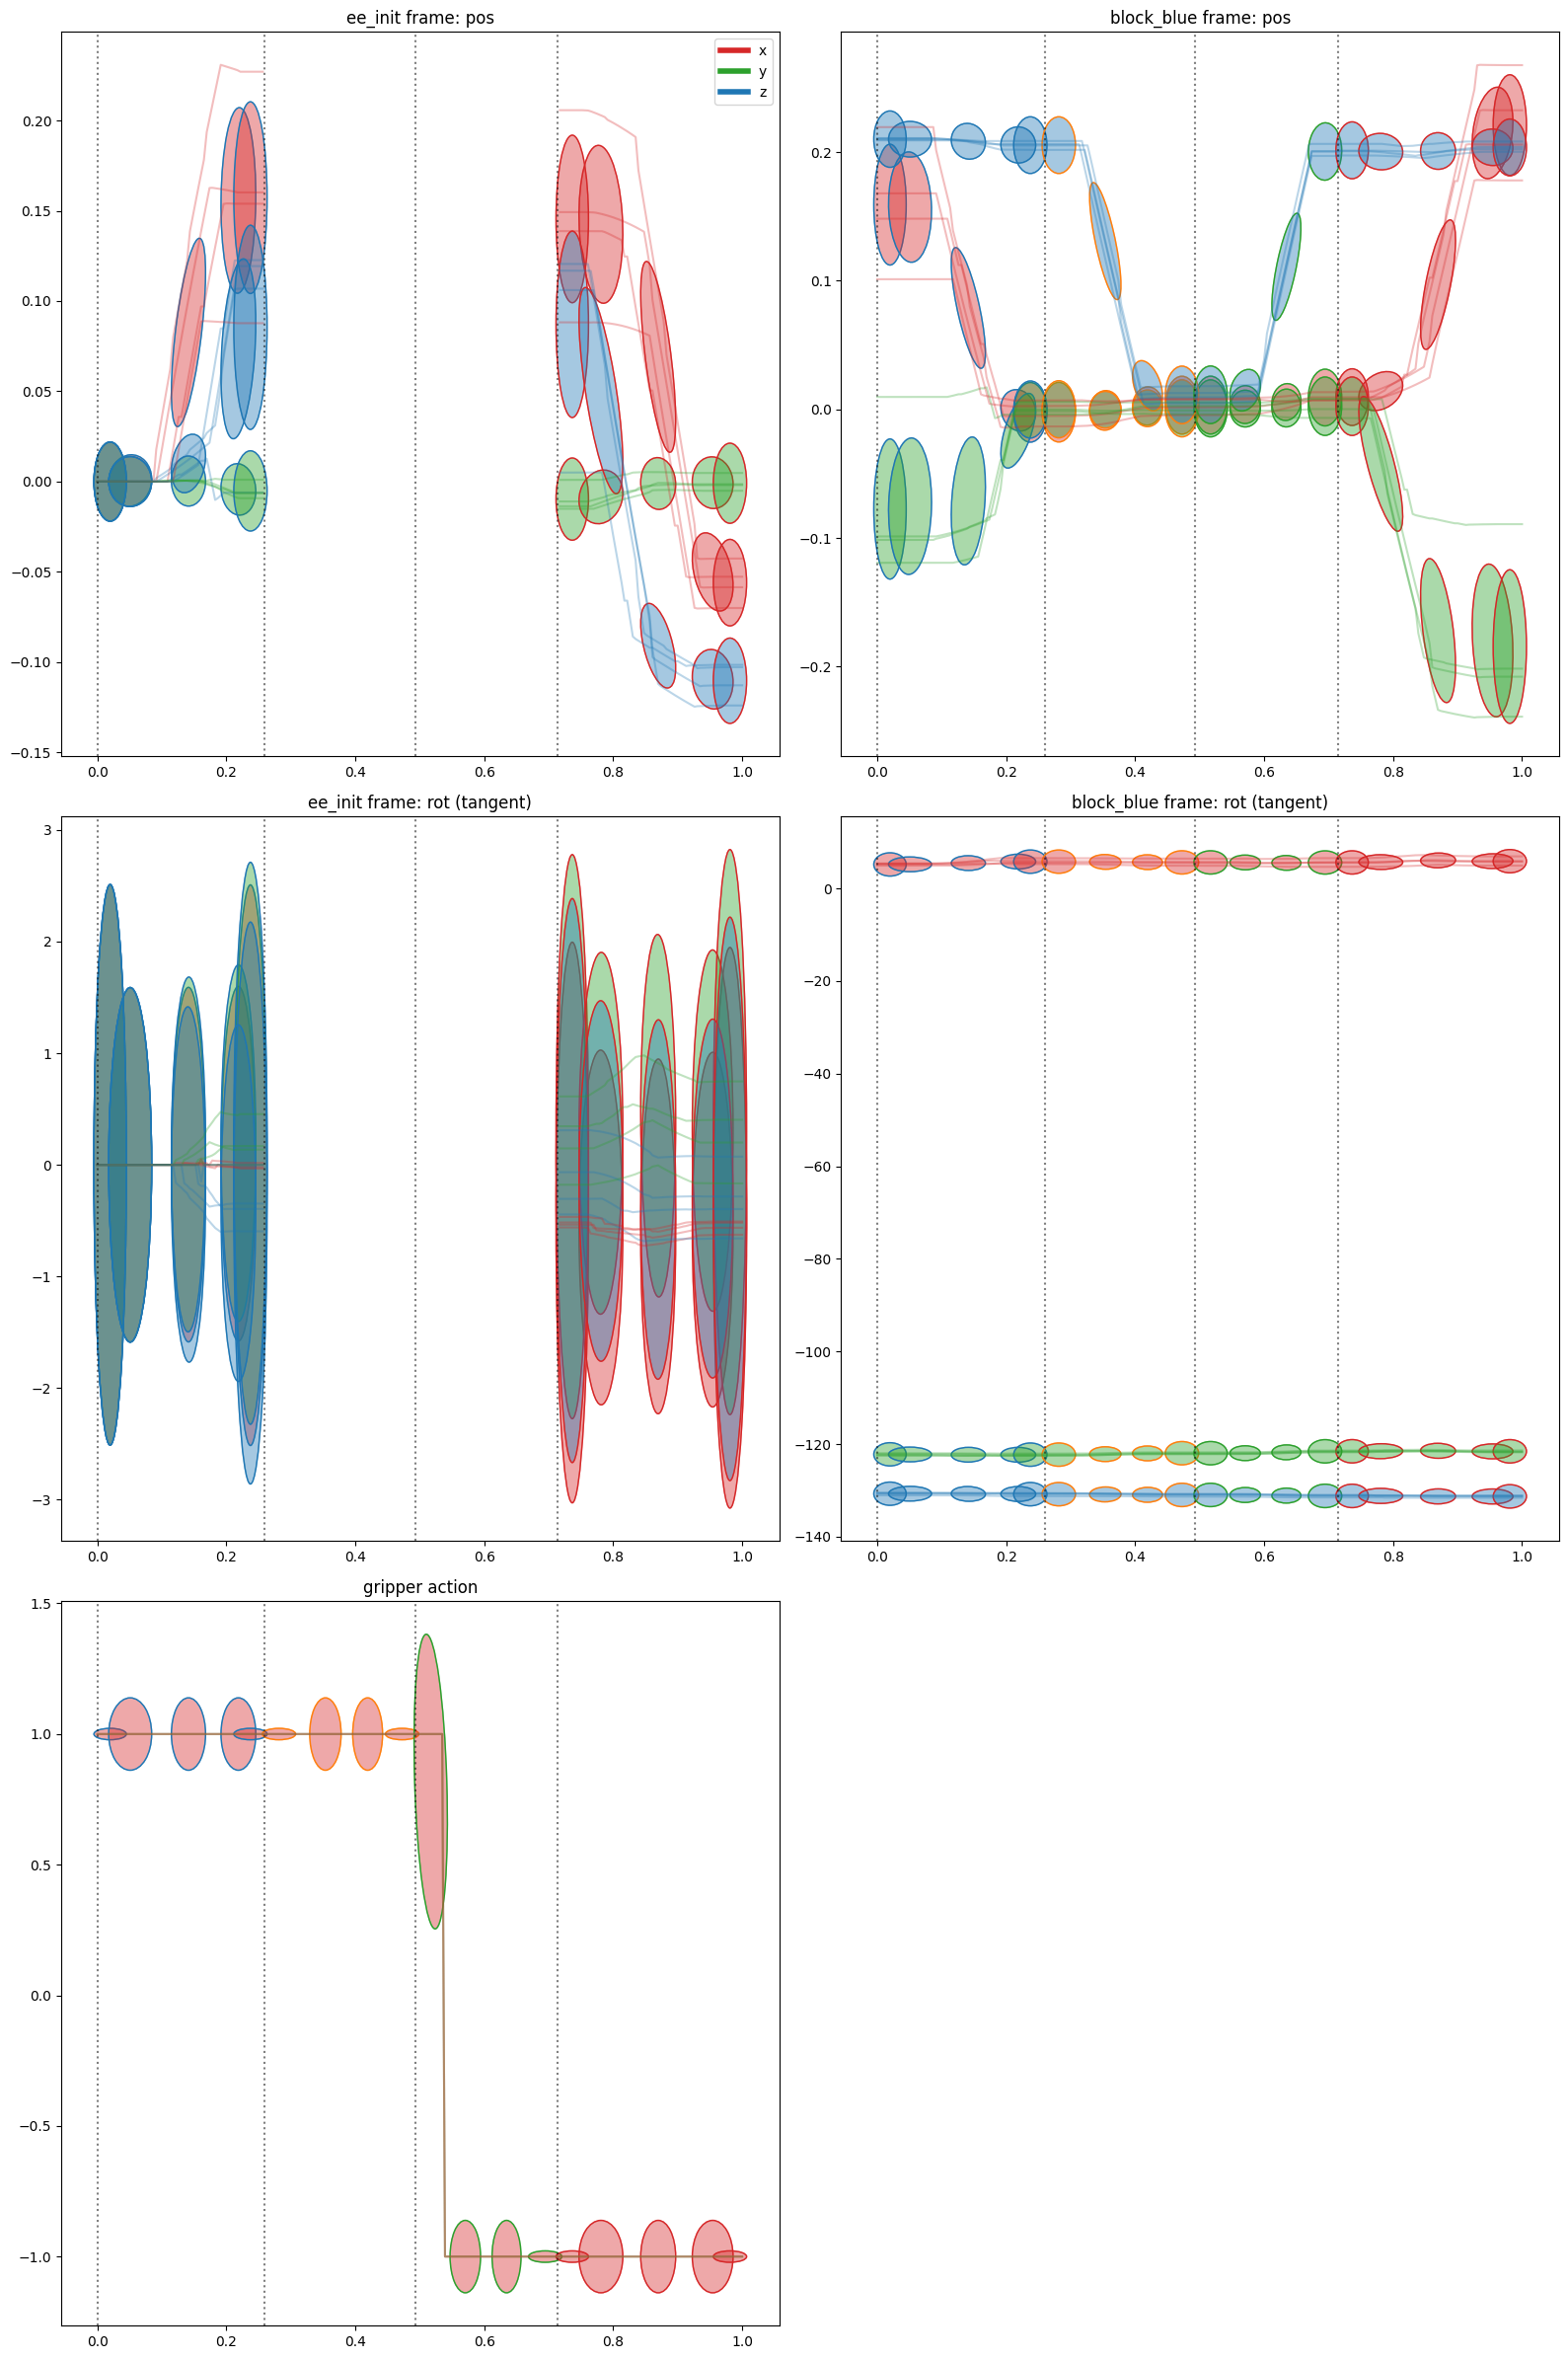

In [29]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

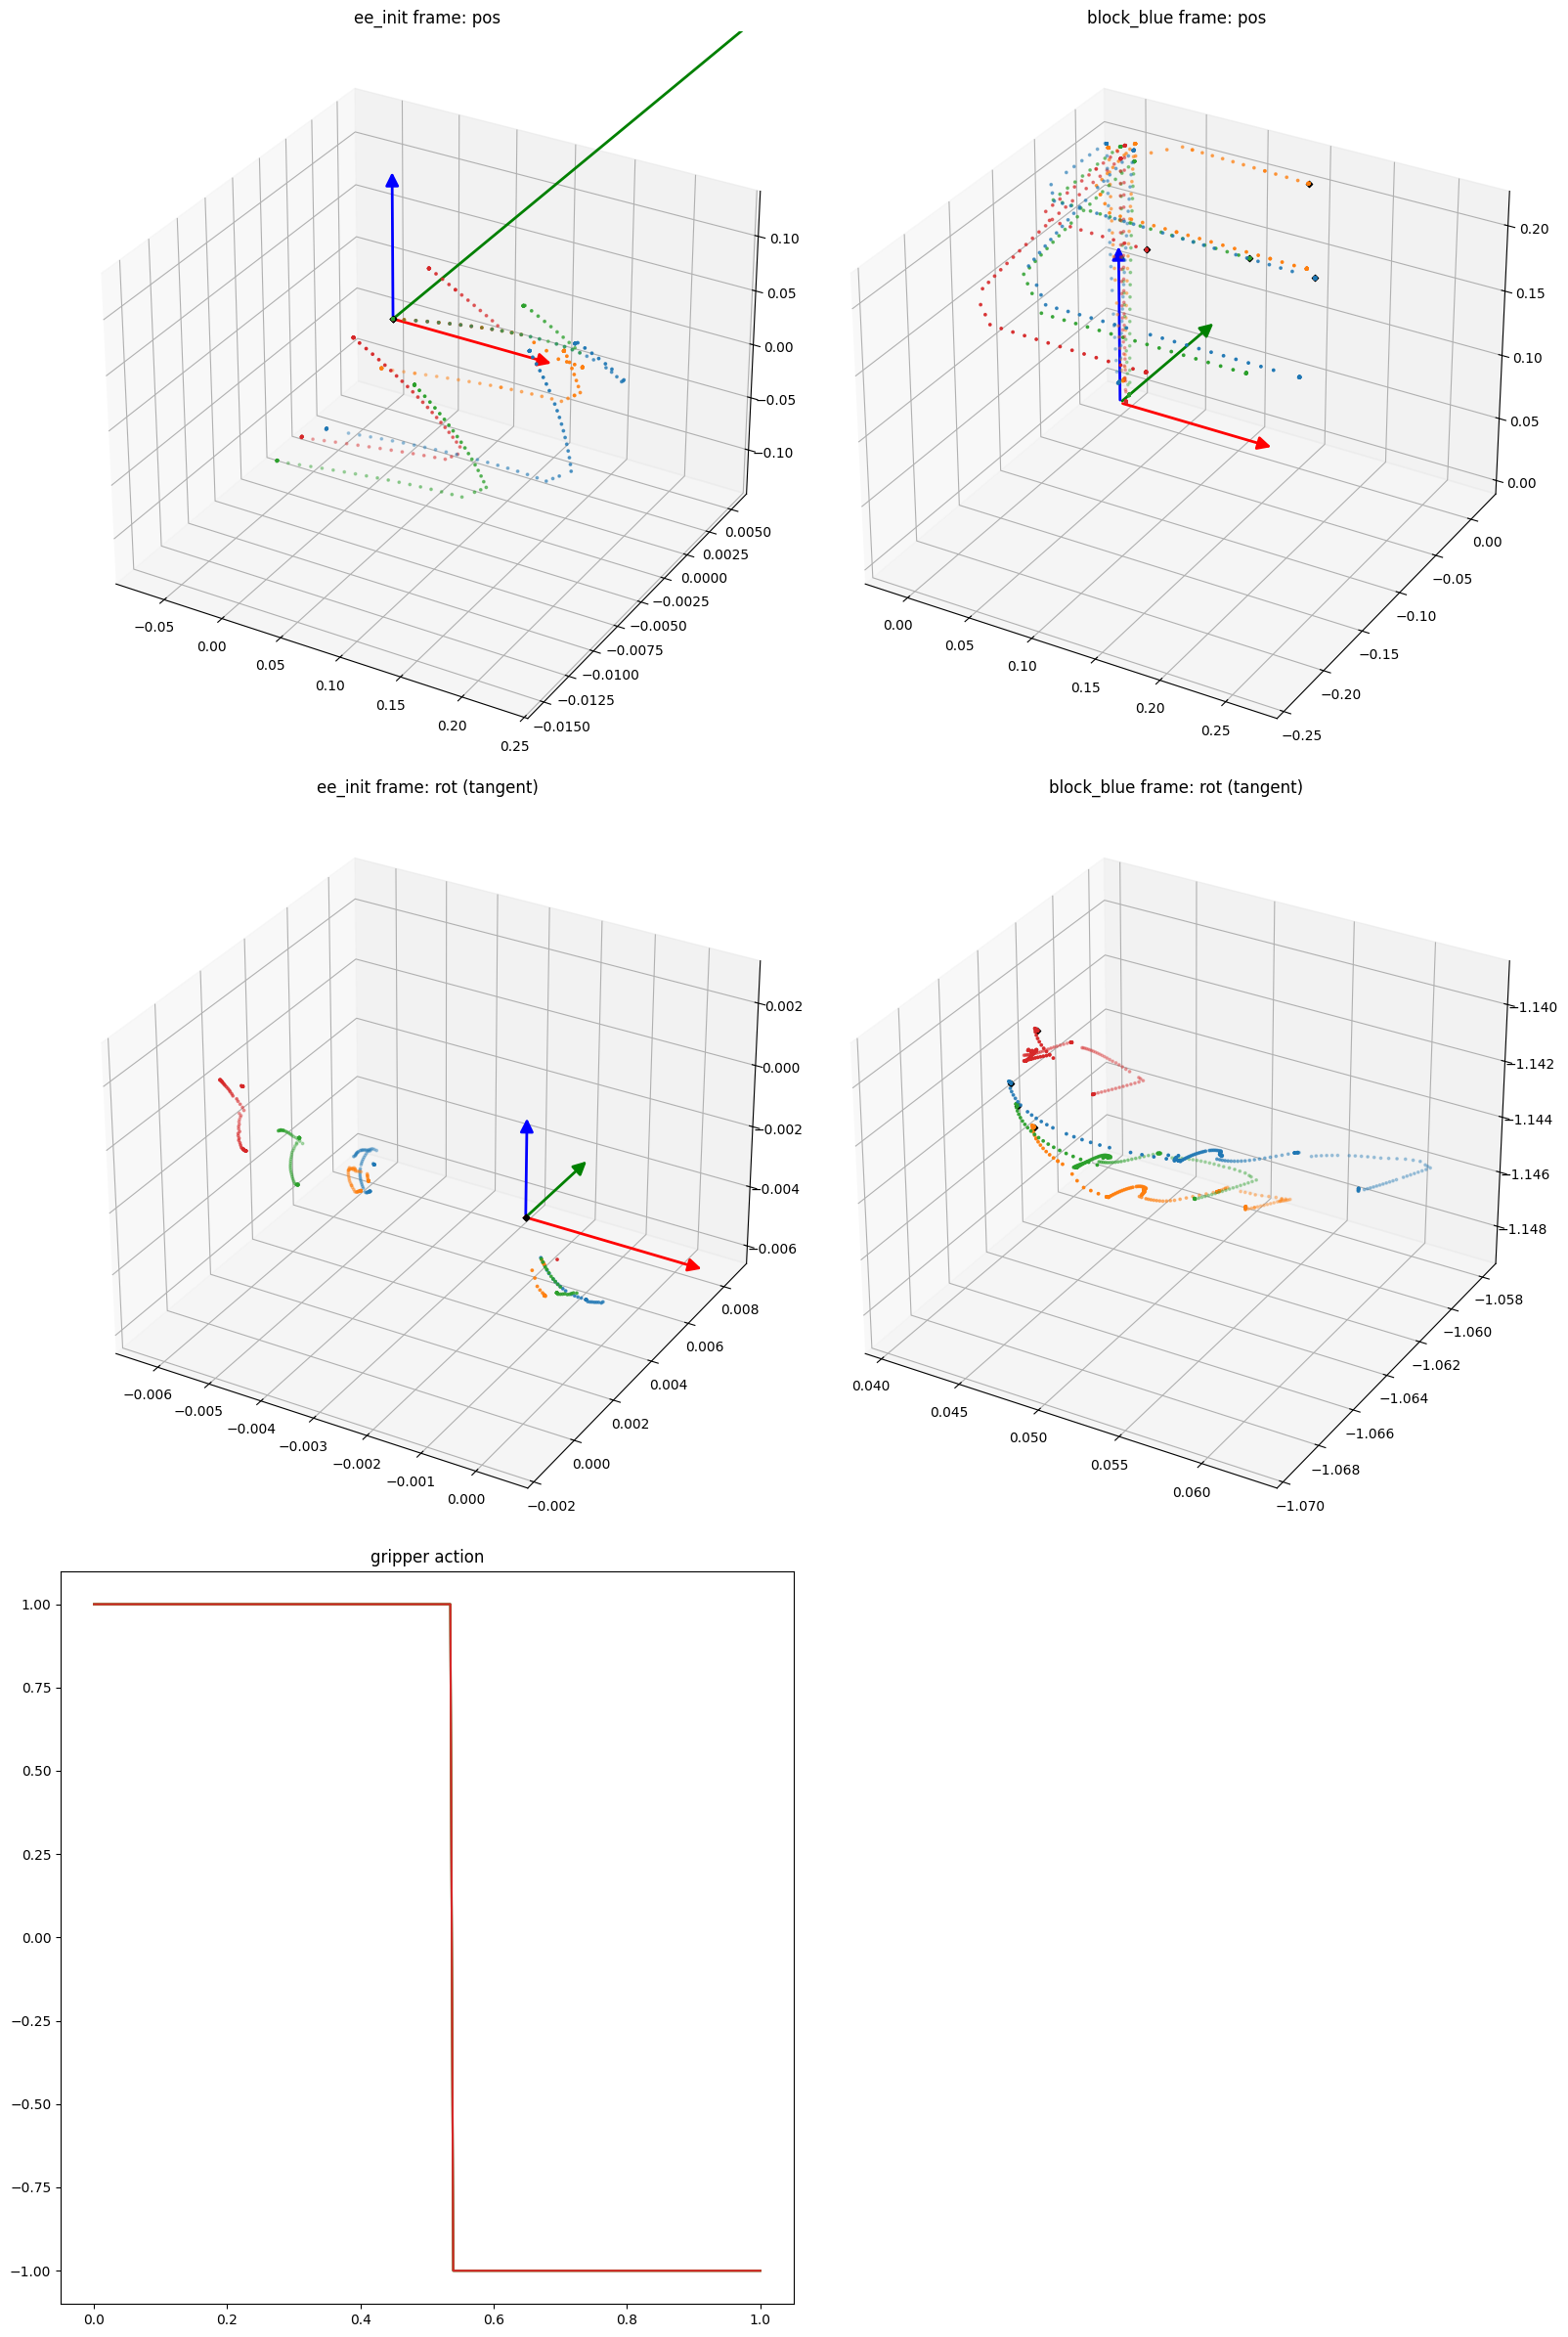

In [30]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=False,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False, time_based=False)

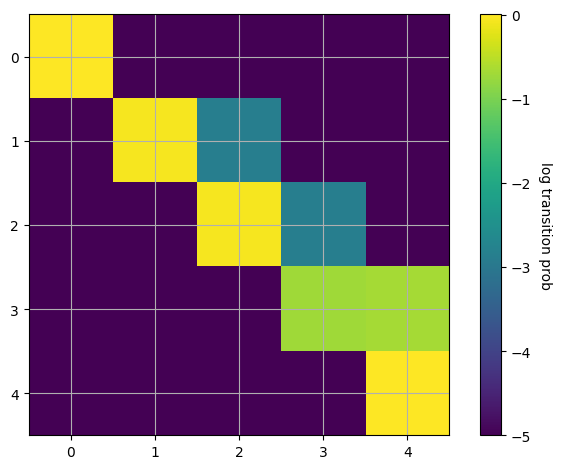

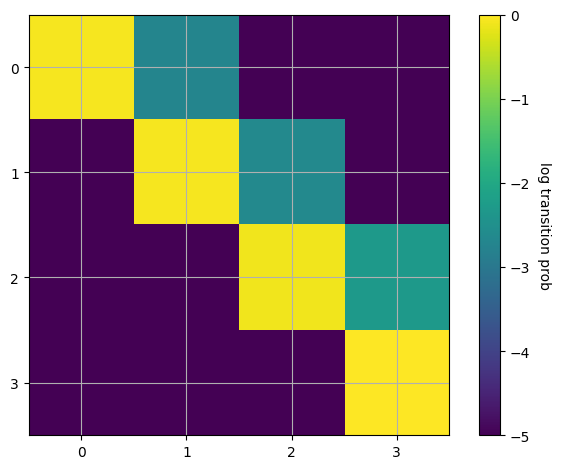

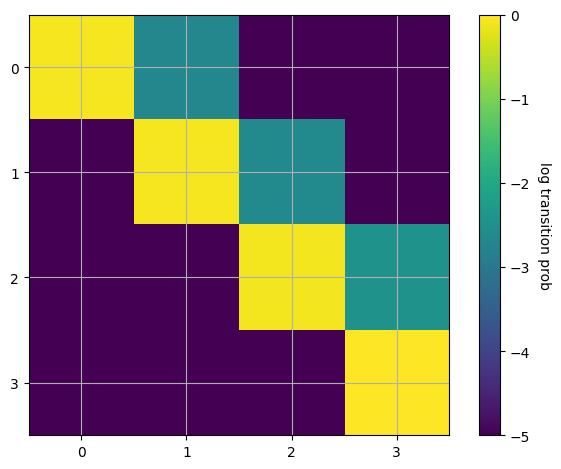

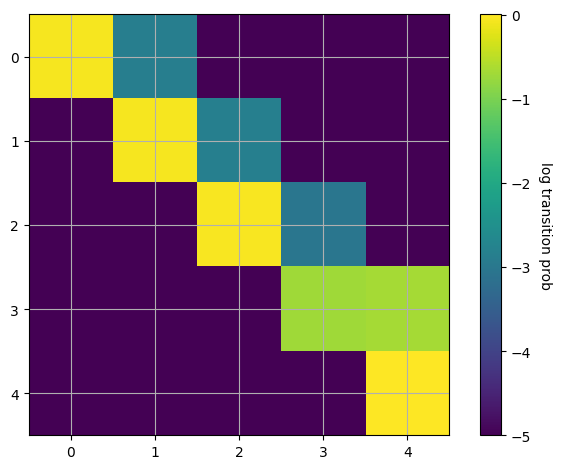

In [31]:
atpgmm.plot_hmm_transition_matrix()

In [32]:
atpgmm.to_disk(data_root / task / 'demos_gmm_policy-release.pt')

In [33]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm_modified.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-17 20:54:16.319 | INFO     |  Caculated segment transition probabilities: (array([[0.25]]), array([[0.24]]), array([[0.26]]))
2025-08-17 20:54:16.319 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:54:16.394 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

...

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

2025-08-17 20:54:16.423 | INFO     |  Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/4 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/4 [00:00<?, ?it/s]

GMR:   0%|          | 0/4 [00:00<?, ?it/s]

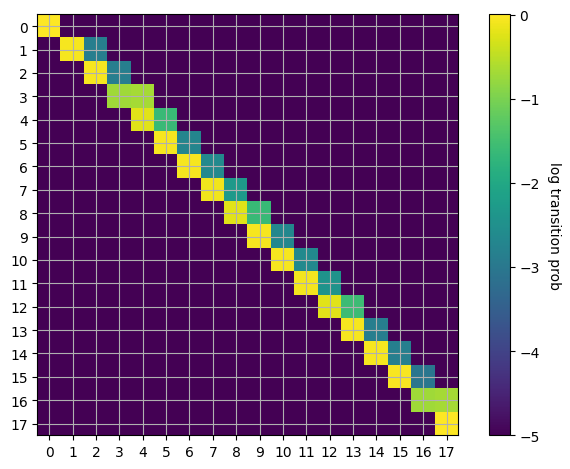

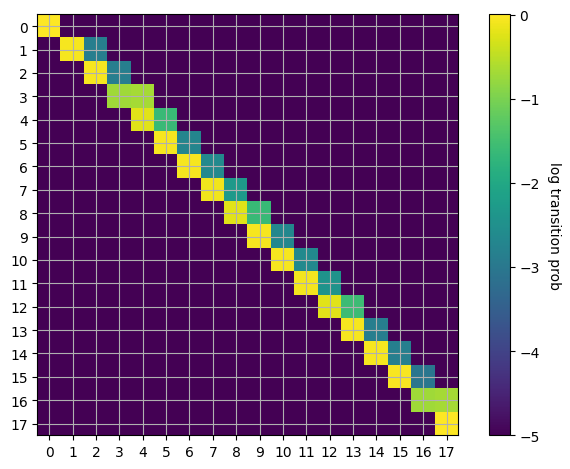

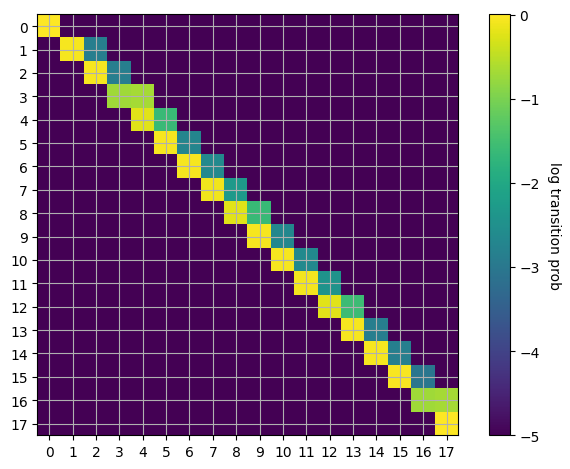

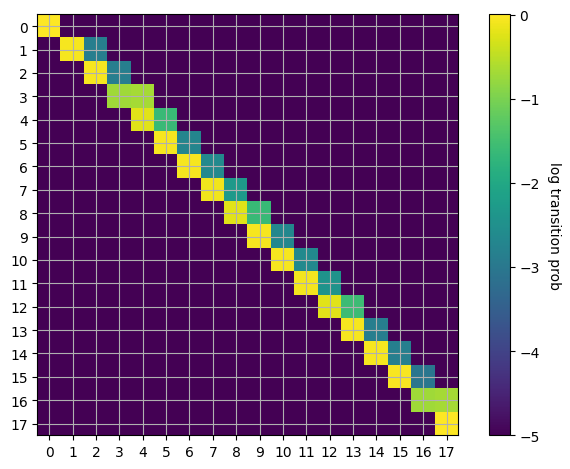

In [34]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-17 20:54:19.635 | INFO     |  Taking frame origins from demos.


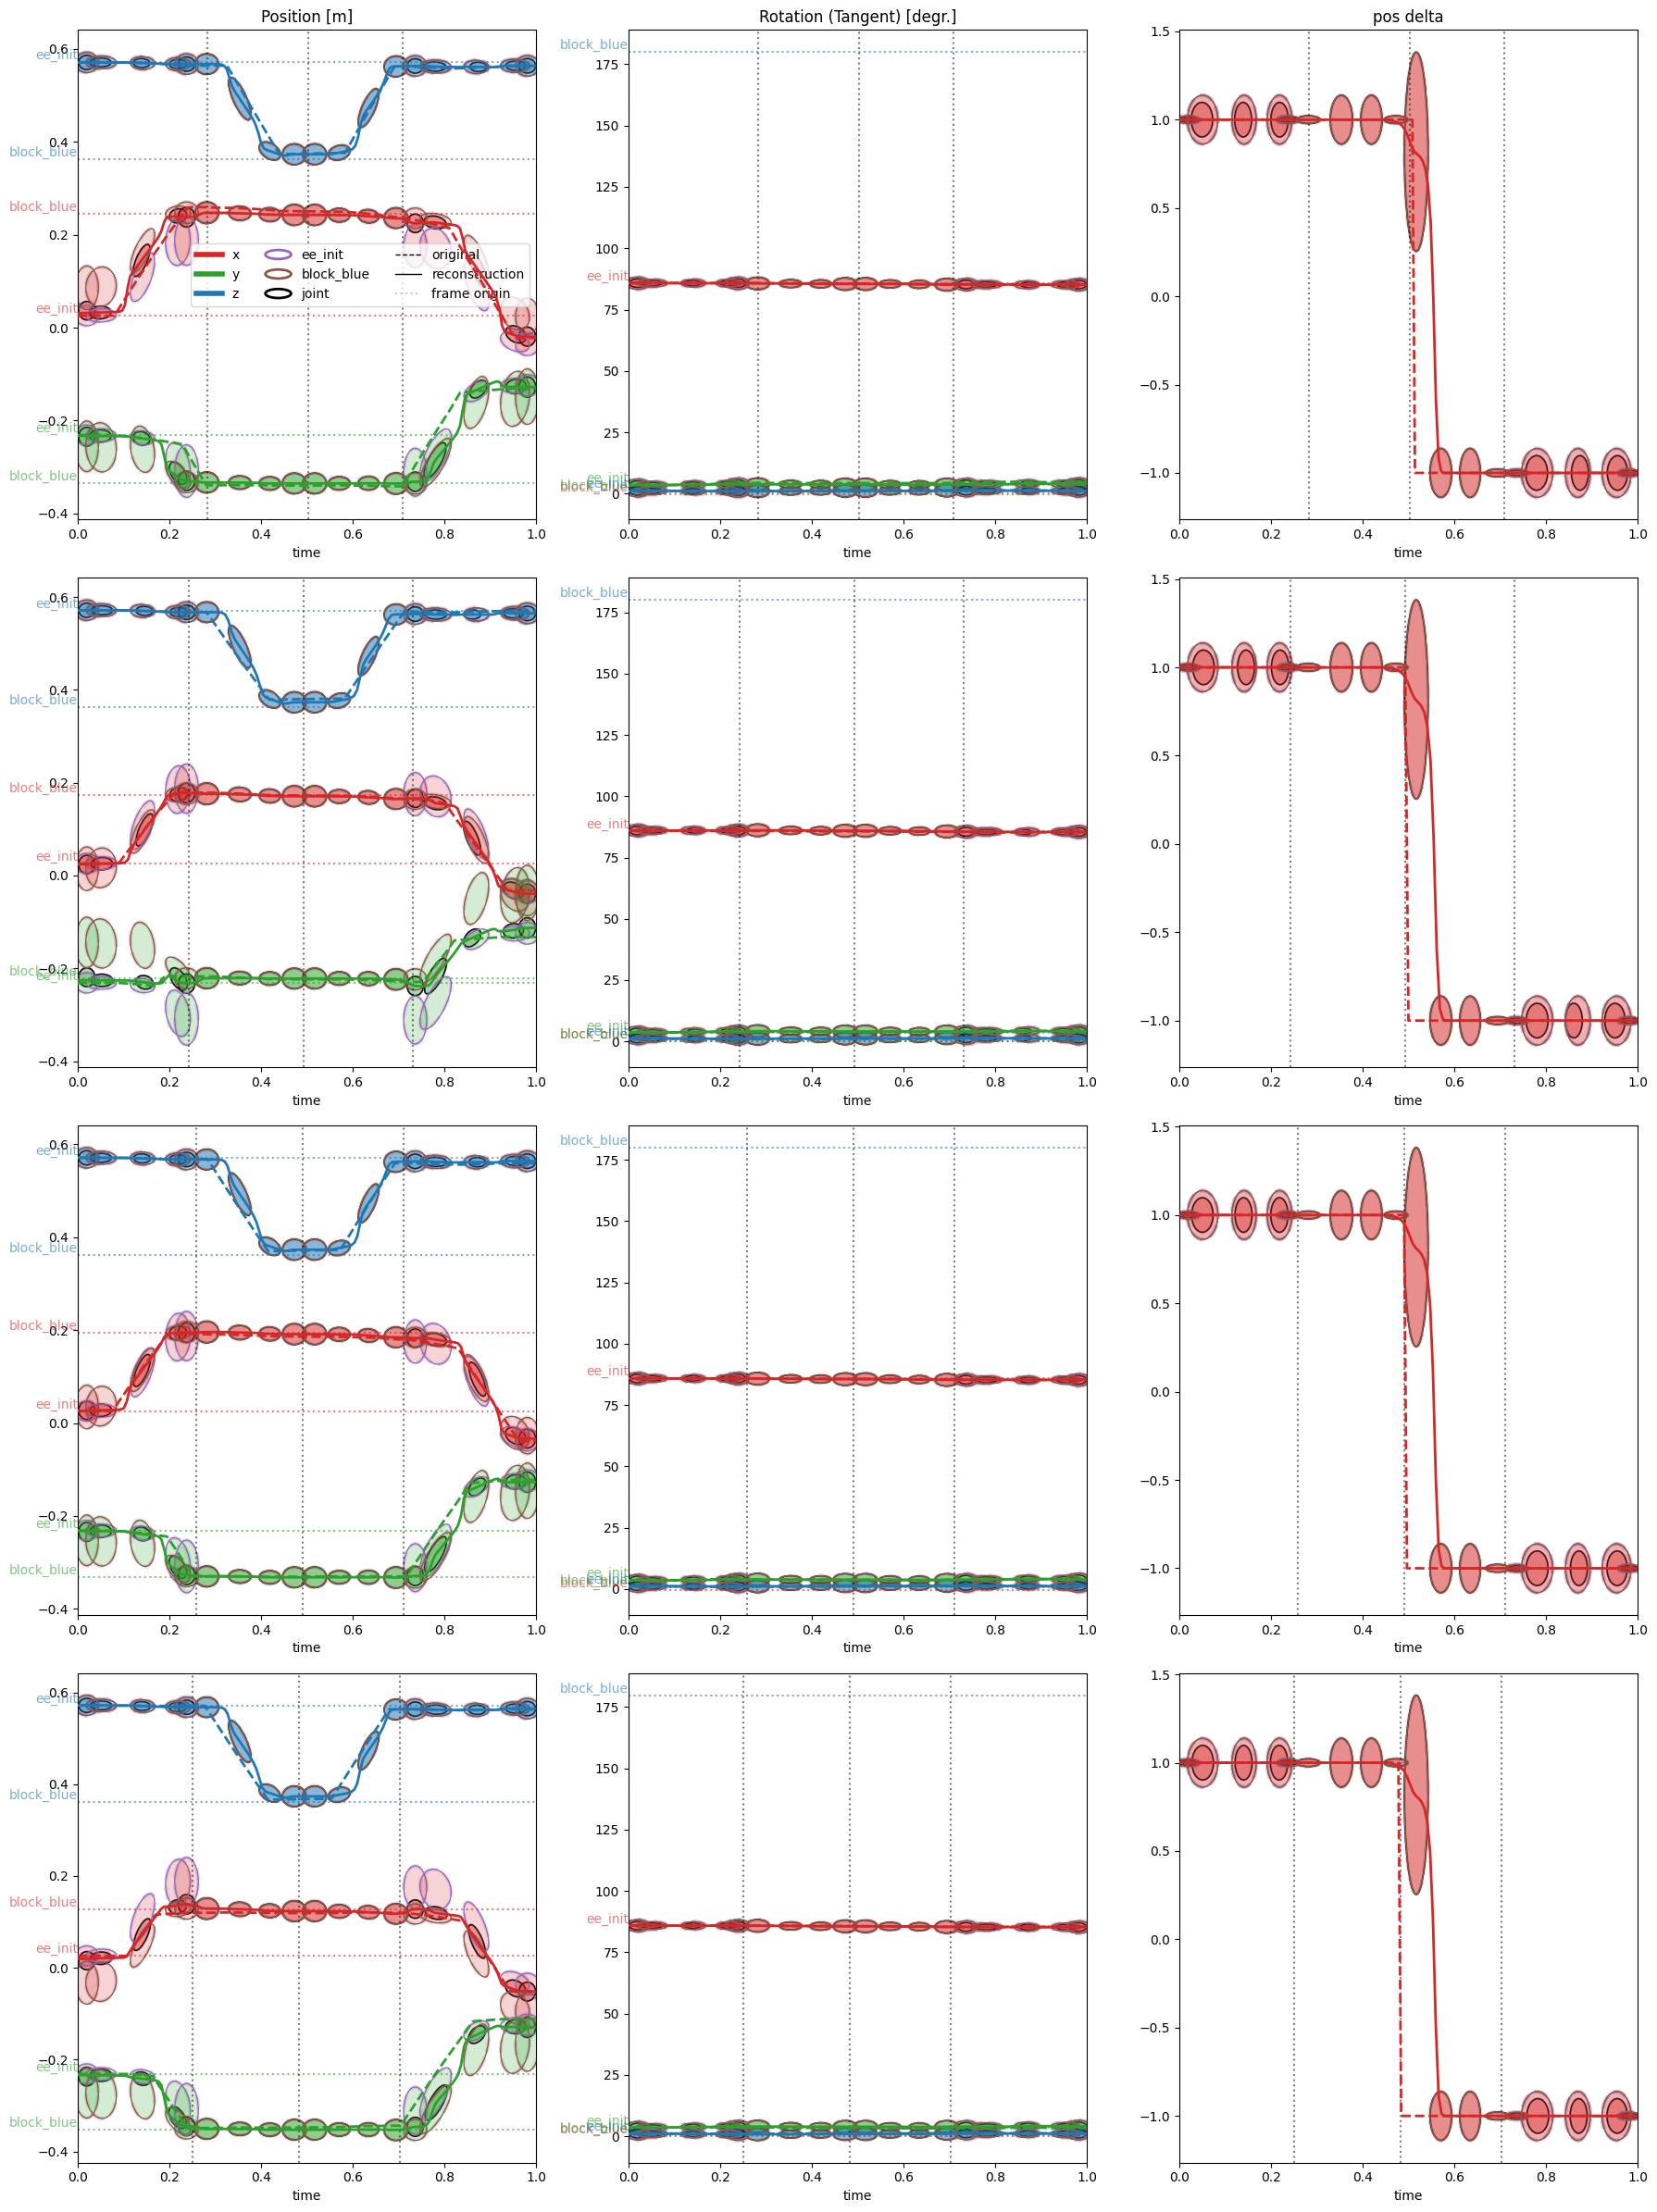

In [35]:

atpgmm.plot_reconstructions(
    seg_trans_marg_container, cascaded_hmms, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=True, equal_aspect=False, per_segment=False)


In [36]:
atpgmm.plot_reconstructions(
    seg_trans_marginals, seg_joint_models, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=False, equal_aspect=True, per_segment=False)


IndexError: tuple index out of range